# 05 - Final Model Evaluation and Comparison

This notebook compares all completed models using the same fixed train/validation/test split.

Models:
1. Baseline CNN
2. Frozen MobileNetV2
3. Fine-Tuned MobileNetV2
4. ResNet18

Final comparison includes:
- Test Accuracy
- Macro Precision
- Macro Recall
- Macro F1-Score
- Best Validation Accuracy
- Training Time
- Number of Correct / Incorrect Predictions
- Confusion Matrices
- Failure Cases
- Final Model Selection

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection"
)

BASELINE_DIR = PROJECT_DIR / "results" / "baseline"
MOBILENET_DIR = PROJECT_DIR / "results" / "mobilenetv2"
RESNET_DIR = PROJECT_DIR / "results" / "resnet18"
COMPARISON_DIR = PROJECT_DIR / "results" / "comparison"

COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project:", PROJECT_DIR.exists())
print("Baseline results:", BASELINE_DIR.exists())
print("MobileNet results:", MOBILENET_DIR.exists())
print("ResNet results:", RESNET_DIR.exists())

Project: True
Baseline results: True
MobileNet results: True
ResNet results: True


In [4]:
def show_files(folder):
    print(f"\n{folder.name}/")
    for item in sorted(folder.iterdir()):
        print("  ", item.name)

show_files(BASELINE_DIR)
show_files(MOBILENET_DIR)
show_files(RESNET_DIR)


baseline/
   confusion_matrix.png
   failure_cases.png
   metrics.csv
   training_accuracy_curve.png
   training_loss_curve.png

mobilenetv2/
   finetuned_classification_report.txt
   finetuned_confusion_matrix.png
   finetuned_metrics.csv
   finetuned_qualitative_results.png
   finetuned_test_predictions.csv
   finetuned_training_accuracy.png
   finetuned_training_loss.png
   frozen_classification_report.txt
   frozen_confusion_matrix.png
   frozen_failure_cases.png
   frozen_metrics.csv
   frozen_qualitative_results.png
   frozen_test_predictions.csv
   frozen_training_accuracy.png
   frozen_training_loss.png
   mobilenetv2_accuracy_curve.png
   mobilenetv2_classification_report.txt
   mobilenetv2_comparison.csv
   mobilenetv2_confusion_matrix.png
   mobilenetv2_failure_cases.png
   mobilenetv2_loss_curve.png
   mobilenetv2_metrics.csv
   mobilenetv2_qualitative_results.png
   mobilenetv2_test_predictions.csv

resnet18/
   classification_report.txt
   confusion_matrix.png
   failure

In [5]:
baseline_df = pd.read_csv(
    BASELINE_DIR / "metrics.csv"
)

frozen_df = pd.read_csv(
    MOBILENET_DIR / "frozen_metrics.csv"
)

finetuned_df = pd.read_csv(
    MOBILENET_DIR / "finetuned_metrics.csv"
)

resnet_df = pd.read_csv(
    RESNET_DIR / "metrics.csv"
)

print("Baseline")
display(baseline_df)

print("Frozen MobileNetV2")
display(frozen_df)

print("Fine-Tuned MobileNetV2")
display(finetuned_df)

print("ResNet18")
display(resnet_df)

Baseline


,model,test_accuracy,macro_precision,macro_recall,macro_f1,best_validation_accuracy,epochs,training_time_seconds
0,Baseline CNN,0.944444,0.944536,0.944444,0.944219,0.955556,5,455.562564


Frozen MobileNetV2


,Metric,Value
0,Accuracy,0.996296
1,Macro Precision,0.996377
2,Macro Recall,0.996296
3,Macro F1-Score,0.996296
4,Best Validation Accuracy,0.996296


Fine-Tuned MobileNetV2


,Metric,Value
0,Accuracy,1.0
1,Macro Precision,1.0
2,Macro Recall,1.0
3,Macro F1-Score,1.0
4,Best Validation Accuracy,1.0


ResNet18


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Best Validation Accuracy,Epochs,Training Time Seconds
0,ResNet18,0.981481,0.981713,0.981481,0.981479,0.988889,10,2059.637449


In [7]:
print("BASELINE COLUMNS:")
print(baseline_df.columns.tolist())

print("\nFROZEN MOBILENETV2 COLUMNS:")
print(frozen_df.columns.tolist())

print("\nFINETUNED MOBILENETV2 COLUMNS:")
print(finetuned_df.columns.tolist())

print("\nRESNET18 COLUMNS:")
print(resnet_df.columns.tolist())


BASELINE COLUMNS:
['model', 'test_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'best_validation_accuracy', 'epochs', 'training_time_seconds']

FROZEN MOBILENETV2 COLUMNS:
['Metric', 'Value']

FINETUNED MOBILENETV2 COLUMNS:
['Metric', 'Value']

RESNET18 COLUMNS:
['Model', 'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Best Validation Accuracy', 'Epochs', 'Training Time Seconds']


In [8]:
print("\n===== BASELINE =====")
display(baseline_df)

print("\n===== FROZEN MOBILENETV2 =====")
display(frozen_df)

print("\n===== FINETUNED MOBILENETV2 =====")
display(finetuned_df)

print("\n===== RESNET18 =====")
display(resnet_df)


===== BASELINE =====


,model,test_accuracy,macro_precision,macro_recall,macro_f1,best_validation_accuracy,epochs,training_time_seconds
0,Baseline CNN,0.944444,0.944536,0.944444,0.944219,0.955556,5,455.562564



===== FROZEN MOBILENETV2 =====


,Metric,Value
0,Accuracy,0.996296
1,Macro Precision,0.996377
2,Macro Recall,0.996296
3,Macro F1-Score,0.996296
4,Best Validation Accuracy,0.996296



===== FINETUNED MOBILENETV2 =====


,Metric,Value
0,Accuracy,1.0
1,Macro Precision,1.0
2,Macro Recall,1.0
3,Macro F1-Score,1.0
4,Best Validation Accuracy,1.0



===== RESNET18 =====


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Best Validation Accuracy,Epochs,Training Time Seconds
0,ResNet18,0.981481,0.981713,0.981481,0.981479,0.988889,10,2059.637449


In [9]:
# Helper to read MobileNet metric-value tables
def get_metric_value(df, metric_name):
    return float(
        df.loc[
            df["Metric"] == metric_name,
            "Value"
        ].iloc[0]
    )


comparison_df = pd.DataFrame([
    {
        "Model": "Baseline CNN",
        "Accuracy": baseline_df.loc[0, "test_accuracy"],
        "Macro Precision": baseline_df.loc[0, "macro_precision"],
        "Macro Recall": baseline_df.loc[0, "macro_recall"],
        "Macro F1": baseline_df.loc[0, "macro_f1"],
        "Best Validation Accuracy":
            baseline_df.loc[0, "best_validation_accuracy"],
        "Epochs":
            baseline_df.loc[0, "epochs"],
        "Training Time Seconds":
            baseline_df.loc[0, "training_time_seconds"]
    },

    {
        "Model": "MobileNetV2 Frozen",
        "Accuracy":
            get_metric_value(
                frozen_df,
                "Accuracy"
            ),
        "Macro Precision":
            get_metric_value(
                frozen_df,
                "Macro Precision"
            ),
        "Macro Recall":
            get_metric_value(
                frozen_df,
                "Macro Recall"
            ),
        "Macro F1":
            get_metric_value(
                frozen_df,
                "Macro F1-Score"
            ),
        "Best Validation Accuracy":
            get_metric_value(
                frozen_df,
                "Best Validation Accuracy"
            ),
        "Epochs": 10,
        "Training Time Seconds": np.nan
    },

    {
        "Model": "MobileNetV2 Fine-Tuned",
        "Accuracy":
            get_metric_value(
                finetuned_df,
                "Accuracy"
            ),
        "Macro Precision":
            get_metric_value(
                finetuned_df,
                "Macro Precision"
            ),
        "Macro Recall":
            get_metric_value(
                finetuned_df,
                "Macro Recall"
            ),
        "Macro F1":
            get_metric_value(
                finetuned_df,
                "Macro F1-Score"
            ),
        "Best Validation Accuracy":
            get_metric_value(
                finetuned_df,
                "Best Validation Accuracy"
            ),
        "Epochs": 5,
        "Training Time Seconds": np.nan
    },

    {
        "Model": "ResNet18",
        "Accuracy":
            resnet_df.loc[0, "Accuracy"],
        "Macro Precision":
            resnet_df.loc[0, "Macro Precision"],
        "Macro Recall":
            resnet_df.loc[0, "Macro Recall"],
        "Macro F1":
            resnet_df.loc[0, "Macro F1"],
        "Best Validation Accuracy":
            resnet_df.loc[0, "Best Validation Accuracy"],
        "Epochs":
            resnet_df.loc[0, "Epochs"],
        "Training Time Seconds":
            resnet_df.loc[0, "Training Time Seconds"]
    }
])

display(comparison_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Best Validation Accuracy,Epochs,Training Time Seconds
0,Baseline CNN,0.944444,0.944536,0.944444,0.944219,0.955556,5,455.562564
1,MobileNetV2 Frozen,0.996296,0.996377,0.996296,0.996296,0.996296,10,NaN
2,MobileNetV2 Fine-Tuned,1.000000,1.000000,1.000000,1.000000,1.000000,5,NaN
3,ResNet18,0.981481,0.981713,0.981481,0.981479,0.988889,10,2059.637449


In [10]:
TOTAL_TEST_IMAGES = 270

comparison_df["Correct Predictions"] = (
    comparison_df["Accuracy"] * TOTAL_TEST_IMAGES
).round().astype(int)

comparison_df["Incorrect Predictions"] = (
    TOTAL_TEST_IMAGES
    - comparison_df["Correct Predictions"]
)

display(
    comparison_df[
        [
            "Model",
            "Accuracy",
            "Correct Predictions",
            "Incorrect Predictions"
        ]
    ]
)

,Model,Accuracy,Correct Predictions,Incorrect Predictions
0,Baseline CNN,0.944444,255,15
1,MobileNetV2 Frozen,0.996296,269,1
2,MobileNetV2 Fine-Tuned,1.000000,270,0
3,ResNet18,0.981481,265,5


In [11]:
display_df = comparison_df.copy()

percentage_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Best Validation Accuracy"
]

for column in percentage_columns:
    display_df[column] = (
        display_df[column] * 100
    )

display(
    display_df.round(2)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Best Validation Accuracy,Epochs,Training Time Seconds,Correct Predictions,Incorrect Predictions
0,Baseline CNN,94.44,94.45,94.44,94.42,95.56,5,455.56,255,15
1,MobileNetV2 Frozen,99.63,99.64,99.63,99.63,99.63,10,NaN,269,1
2,MobileNetV2 Fine-Tuned,100.00,100.00,100.00,100.00,100.00,5,NaN,270,0
3,ResNet18,98.15,98.17,98.15,98.15,98.89,10,2059.64,265,5


In [12]:
comparison_df.to_csv(
    COMPARISON_DIR / "model_comparison.csv",
    index=False
)

print("Saved final comparison table.")

Saved final comparison table.


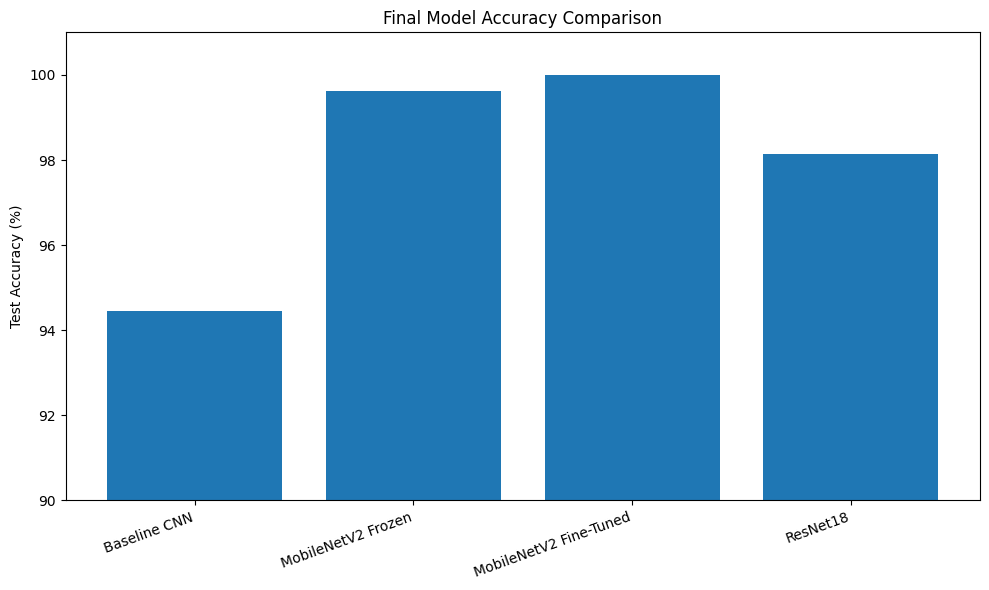

In [13]:
plt.figure(figsize=(10, 6))

plt.bar(
    display_df["Model"],
    display_df["Accuracy"]
)

plt.ylabel("Test Accuracy (%)")
plt.title("Final Model Accuracy Comparison")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(90, 101)

plt.tight_layout()

plt.savefig(
    COMPARISON_DIR / "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

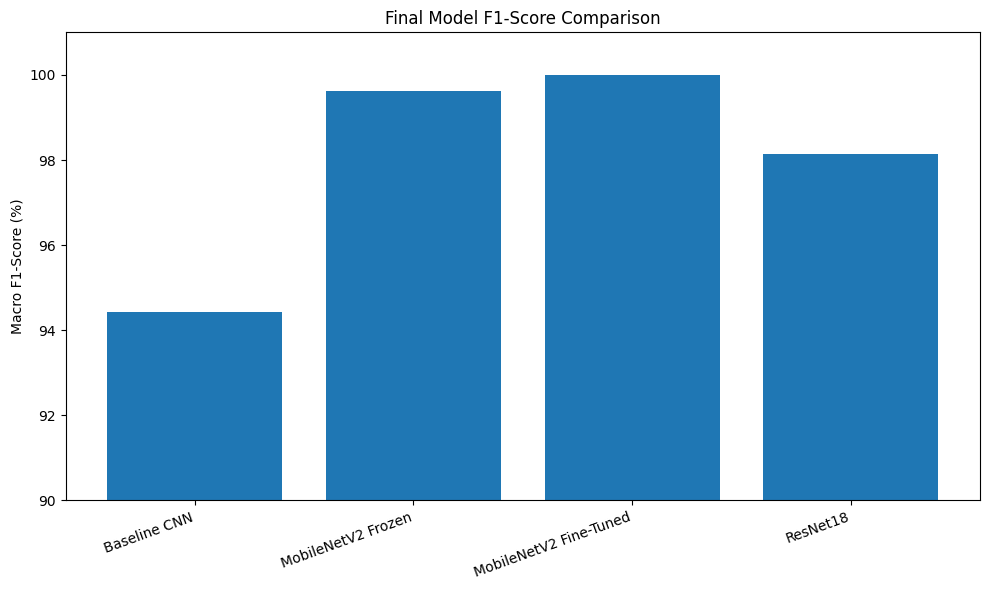

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    display_df["Model"],
    display_df["Macro F1"]
)

plt.ylabel("Macro F1-Score (%)")
plt.title("Final Model F1-Score Comparison")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(90, 101)

plt.tight_layout()

plt.savefig(
    COMPARISON_DIR / "f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

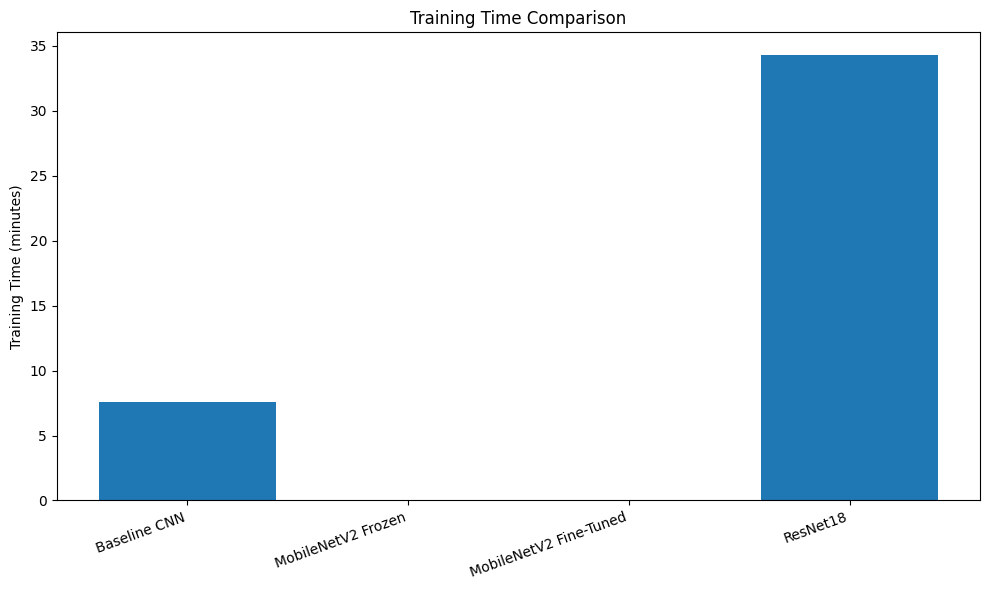

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time Seconds"] / 60
)

plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    COMPARISON_DIR / "training_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
best_index = (
    comparison_df["Accuracy"]
    .idxmax()
)

best_model = comparison_df.loc[
    best_index
]

print(
    "Best model:",
    best_model["Model"]
)

print(
    f"Test Accuracy: "
    f"{best_model['Accuracy'] * 100:.2f}%"
)

print(
    f"Macro F1: "
    f"{best_model['Macro F1'] * 100:.2f}%"
)

Best model: MobileNetV2 Fine-Tuned
Test Accuracy: 100.00%
Macro F1: 100.00%


In [17]:
final_table = display_df[
    [
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Correct Predictions",
        "Incorrect Predictions"
    ]
].copy()

final_table = final_table.round(2)

display(final_table)

final_table.to_csv(
    COMPARISON_DIR / "final_results_table.csv",
    index=False
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Correct Predictions,Incorrect Predictions
0,Baseline CNN,94.44,94.45,94.44,94.42,255,15
1,MobileNetV2 Frozen,99.63,99.64,99.63,99.63,269,1
2,MobileNetV2 Fine-Tuned,100.00,100.00,100.00,100.00,270,0
3,ResNet18,98.15,98.17,98.15,98.15,265,5
